In [3]:
from brian2 import *
%matplotlib inline

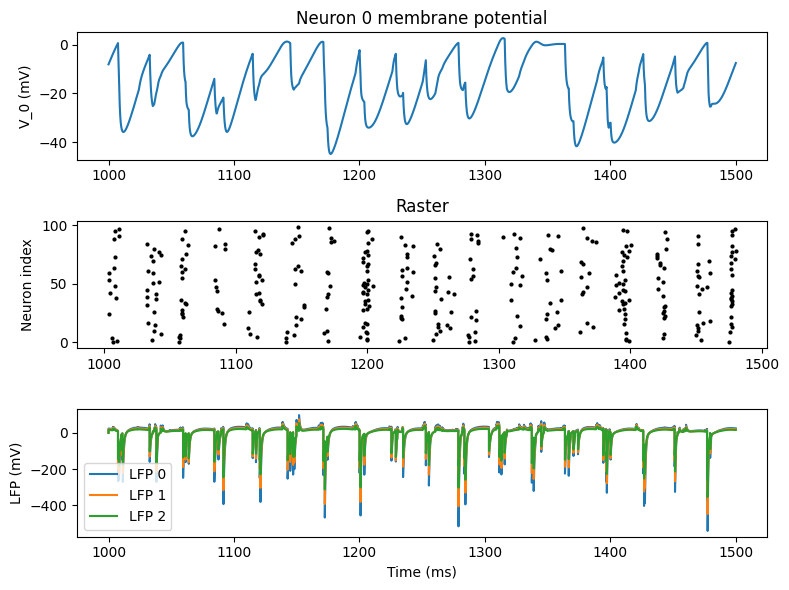

In [45]:
from brian2 import *

start_scope()
defaultclock.dt = 0.01*ms

# ==========================
# 1. HH 神经元参数（点神经元）
# ==========================
Cm  = 1*uF/cm**2
Cm  = Cm * (1*cm**2)        # 假设每个神经元面积 = 1 cm^2 → F
El  = 10.613*mV
ENa = 115*mV
EK  = -12*mV
gl  = 0.3*msiemens/cm**2 * (1*cm**2)   # -> siemens
gNa = 120*msiemens/cm**2 * (1*cm**2)   # -> siemens
gK  = 36*msiemens/cm**2 * (1*cm**2)    # -> siemens

# 突触参数
E_exc = 0*mV
E_inh = -80*mV
tau_e = 5*ms
tau_i = 10*ms

# ==========================
# 2. 多神经元 HH 方程（点神经元）
#    Im 用 amp，方便 LFP 使用 v_post = w*Im_pre
#    ★ 在这里加上 x,y,z 三个位置参数
# ==========================
eqs = '''
Im = gl * (El-v) + gNa * m**3 * h * (ENa-v) + gK * n**4 * (EK-v)
     + ge * (E_exc-v) + gi * (E_inh-v) + I_inj : amp

dv/dt = Im / Cm : volt

dge/dt = -ge/tau_e : siemens
dgi/dt = -gi/tau_i : siemens

I_inj : amp   # 外加电流

dm/dt = alpham * (1-m) - betam * m : 1
dn/dt = alphan * (1-n) - betan * n : 1
dh/dt = alphah * (1-h) - betah * h : 1

alpham = (0.1/mV) * 10*mV/exprel((-v+25*mV)/(10*mV))/ms : Hz
betam = 4 * exp(-v/(18*mV))/ms : Hz
alphah = 0.07 * exp(-v/(20*mV))/ms : Hz
betah = 1/(exp((-v+30*mV) / (10*mV)) + 1)/ms : Hz
alphan = (0.01/mV) * 10*mV/exprel((-v+10*mV)/(10*mV))/ms : Hz
betan = 0.125*exp(-v/(80*mV))/ms : Hz

# ★ 位置（参数，不随时间变化）
x : meter
y : meter
z : meter
'''

# ==========================
# 3. 建一个 E/I 群体：多 HH 神经元
# ==========================
N = 100          # 先从 5 试起
frac_exc = 0.8
N_exc = int(N*frac_exc)
N_inh = N - N_exc

G = NeuronGroup(N, eqs,
                threshold='v > 0*mV',
                refractory='v > -30*mV',   # 稍微合理一点的不应期条件
                method='exponential_euler')

# 初始化
G.v = El
G.m = 0
G.h = 1
G.n = 0
G.ge = 0*siemens
G.gi = 0*siemens
G.I_inj = 0*amp

# ★ 给神经元布置空间位置（简单地排成一条线）
#   比如 x 方向上间隔 100 µm，全部在 y=z=0 上
G.x = 'i * 100*um'   # i: 神经元索引 0..N-1
G.y = 0*um
G.z = 0*um

Ge = G[:N_exc]
Gi = G[N_exc:]

# ==========================
# 4. E/I 突触（电导型）
# ==========================
p_conn = 0.5

w_e = 0.1*msiemens   # 兴奋性单个突触电导
w_i = 0.3*msiemens   # 抑制性单个突触电导

# E → 所有
S_ee = Synapses(Ge, G, on_pre='ge_post += w_e')
S_ee.connect(p=p_conn)

# I → 所有人
S_ie = Synapses(Gi, G, on_pre='gi_post += w_i')
S_ie.connect(p=p_conn)

# （可选）背景 Poisson 兴奋输入
P = PoissonGroup(N_exc, rates=5*Hz)
S_ext = Synapses(P, Ge, on_pre='ge_post += 0.1*msiemens')
S_ext.connect(j='i')  # 一一对应

# 给一小群 E 神经元一点持续注入电流，启动网络
G.I_inj[:min(10, N)] = 0.5*uA

# ==========================
# 5. LFP 记录（多电极 + 距离衰减 1/r）
# ==========================
Ne = 3   # 3 个“电极”
sigma = 0.3*siemens/meter      # 组织电导率
rho = 1/sigma                  # 组织电阻率 (ohm * meter), 正式公式用到 ρ/(4πr)

# ★ 电极也有位置
lfp = NeuronGroup(Ne, '''
v : volt
x : meter
y : meter
z : meter
''')
lfp.v = 0*mV

# 布置电极位置：
#   - x 固定在网络中间
#   - y 距离依次增大，z=0
center_x = (N-1)/2 * 100*um
lfp.x = center_x
lfp.y = [200*um, 400*um, 800*um]   # 距离逐渐增大
lfp.z = 0*um

# 用 Synapses 把所有神经元连到所有电极
# 模式： v_post = w * Im_pre （Im_pre 单位 A, w 单位 ohm → v 单位 volt）
S_lfp = Synapses(G, lfp,
                 model='''
                 w : ohm (constant)
                 v_post = w * Im_pre : volt (summed)
                 ''')

S_lfp.connect()   # 所有神经元 → 所有电极

# ★ 根据 ρ/(4πr) 设置 w，r 为神经元到电极的距离
#   r = sqrt((x_pre-x_post)^2 + (y_pre-y_post)^2 + (z_pre-z_post)^2)
#   ρ/(4πr) 单位 = (ohm*m) / m = ohm
S_lfp.w = 'rho / (4*pi*sqrt((x_pre-x_post)**2 + (y_pre-y_post)**2 + (z_pre-z_post)**2))'

# 为了避免特别大的数值，你也可以再整体缩放一下，例如：
# S_lfp.w = 'rho / (4*pi*sqrt((x_pre-x_post)**2 + (y_pre-y_post)**2 + (z_pre-z_post)**2)) / 10'

# 监视
M_v = StateMonitor(G, 'v', record=0)          # 看 0 号神经元
M_lfp = StateMonitor(lfp, 'v', record=True)   # 看所有电极的 LFP 轨迹
spikes = SpikeMonitor(G)

# ==========================
# 6. 预热 + 正式仿真
# ==========================
# 先让网络“预热”，不太在意这段 LFP
run(1000*ms)

# 然后清零 LFP、电极状态，重新开监视器
lfp.v = 0*mV
M_lfp = StateMonitor(lfp, 'v', record=True)
M_v = StateMonitor(G, 'v', record=0)
spikes = SpikeMonitor(G)

# 正式仿真+记录
run(500*ms)

# ==========================
# 7. 画图
# ==========================
figure(figsize=(8,6))
subplot(3,1,1)
plot(M_v.t/ms, M_v.v[0]/mV)
ylabel('V_0 (mV)')
title('Neuron 0 membrane potential')

subplot(3,1,2)
plot(spikes.t/ms, spikes.i, '.k', markersize=4)
ylabel('Neuron index')
title('Raster')

subplot(3,1,3)
for i in range(Ne):
    plot(M_lfp.t/ms, M_lfp.v[i]/mV, label=f'LFP {i}')
ylabel('LFP (mV)')
xlabel('Time (ms)')
legend()
tight_layout()
show()
